# PROJECT

### BUSINESS UNDERSTANDING

 "PHASE-4-project-Group1-DS-PT13"

## BUSINESS PROBLEM
On social media, consumer perceptions of technology products change quickly and openly. As two of the most talked-about tech companies in the world, Apple and Google receive thousands of mentions every day on Twitter. However, neither company nor its partners have a scalable method to track the real-time reception of product launches, updates, or service outages. This amount of tweets cannot be manually reviewed, and traditional survey-based feedback is too slow and too limited to capture natural public opinion.

## PROBLEM STATEMENT
This project develops a natural language processing model that automatically categorises tweet sentiment as positive, negative, or neutral using a labelled dataset of more than 9,000 tweets about Apple and Google products. The objective is to offer a proof-of-concept sentiment classification system that can assist stakeholders and technology brands in comprehending public opinion at scale without the need for manual review.

## STAKEHOLDERS
1. Product Teams -
Product decisions are directly influenced by the model's output. Without waiting for official feedback cycles, product teams can determine where user pain points exist and which features are resonating by knowing whether sentiment surrounding a product is primarily negative, positive, or neutral.
2. Marketing -
In real time, marketing must determine whether campaigns and product launches are succeeding. They can instantly assess public opinion by using a sentiment classifier on Twitter data, which enables them to modify messaging if negative sentiment is rising.
3. Corporate Communications -
This group oversees brand reputation and public perception. Before it becomes a news story, automated sentiment classification provides them with early warning when negative sentiment surrounding a product or event is growing, so they are able to take action
4. Investors - Investors can use the model's output to track brand sentiment trends over time, giving them an early signal on public perception of Apple and Google products. Shifts in sentiment — especially around major product launches or controversies — can inform investment decisions and risk assessments.

### Import necessary libararies

In [36]:
import pandas as pd
import re

### Load the dataset

In [37]:
df = pd.read_csv('judge.csv')

### Explore the data

In [38]:
df.columns

Index(['tweet_text', 'emotion_in_tweet_is_directed_at',
       'is_there_an_emotion_directed_at_a_brand_or_product'],
      dtype='object')

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8721 entries, 0 to 8720
Data columns (total 3 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   tweet_text                                          8720 non-null   object
 1   emotion_in_tweet_is_directed_at                     3169 non-null   object
 2   is_there_an_emotion_directed_at_a_brand_or_product  8721 non-null   object
dtypes: object(3)
memory usage: 204.5+ KB


In [40]:
df.head(10)

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion
5,@teachntech00 New iPad Apps For #SpeechTherapy...,NaN,No emotion toward brand or product
6,NaN,NaN,No emotion toward brand or product
7,"#SXSW is just starting, #CTIA is around the co...",Android,Positive emotion
8,Beautifully smart and simple idea RT @madebyma...,iPad or iPhone App,Positive emotion
9,Counting down the days to #sxsw plus strong Ca...,Apple,Positive emotion


In [41]:
#df = df.dropna()
df.head(10)

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion
5,@teachntech00 New iPad Apps For #SpeechTherapy...,NaN,No emotion toward brand or product
6,NaN,NaN,No emotion toward brand or product
7,"#SXSW is just starting, #CTIA is around the co...",Android,Positive emotion
8,Beautifully smart and simple idea RT @madebyma...,iPad or iPhone App,Positive emotion
9,Counting down the days to #sxsw plus strong Ca...,Apple,Positive emotion


In [42]:
df.isnull().sum()

tweet_text                                               1
emotion_in_tweet_is_directed_at                       5552
is_there_an_emotion_directed_at_a_brand_or_product       0
dtype: int64

In [43]:
df['is_there_an_emotion_directed_at_a_brand_or_product'].isnull().sum()

0

In [44]:

# Drop rows where sentiment column is i can't tell- keep all rows where sentiment does not equal to i cant telll
df = df[df['is_there_an_emotion_directed_at_a_brand_or_product'] != "I can't tell"]


In [45]:
df['is_there_an_emotion_directed_at_a_brand_or_product'].value_counts()

No emotion toward brand or product    5156
Positive emotion                      2869
Negative emotion                       545
Name: is_there_an_emotion_directed_at_a_brand_or_product, dtype: int64

In [46]:
df['emotion_in_tweet_is_directed_at'].isnull().sum()
df['emotion_in_tweet_is_directed_at'].value_counts()

iPad                               906
Apple                              638
iPad or iPhone App                 451
Google                             411
iPhone                             287
Other Google product or service    281
Android App                         78
Android                             74
Other Apple product or service      34
Name: emotion_in_tweet_is_directed_at, dtype: int64

In [47]:
df['is_there_an_emotion_directed_at_a_brand_or_product'].value_counts()
# merge i canttell and no emotion toward brand or product
# rename columns



No emotion toward brand or product    5156
Positive emotion                      2869
Negative emotion                       545
Name: is_there_an_emotion_directed_at_a_brand_or_product, dtype: int64

### sentiments here are either to a specific product or general brand 

### Dropping columns with no tweets

In [48]:
# drop all rows with tweet_text null
df = df.dropna(subset=['tweet_text'])
df.head(10)


,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion
5,@teachntech00 New iPad Apps For #SpeechTherapy...,NaN,No emotion toward brand or product
7,"#SXSW is just starting, #CTIA is around the co...",Android,Positive emotion
8,Beautifully smart and simple idea RT @madebyma...,iPad or iPhone App,Positive emotion
9,Counting down the days to #sxsw plus strong Ca...,Apple,Positive emotion
10,Excited to meet the @samsungmobileus at #sxsw ...,Android,Positive emotion


### Primary task: product-level sentiment analysis- rate whether positive negative or neutral based on products eg ipad or android app
### Secondary: rank brands on hot topics eg battery performance, camera quality etc., rank brands top positve and negative sentiment topics eg pros and cons of apple vs pros and cons of google

## Examining and dealing with null values

In [49]:
df.isnull().sum()

tweet_text                                               0
emotion_in_tweet_is_directed_at                       5409
is_there_an_emotion_directed_at_a_brand_or_product       0
dtype: int64

In [50]:
df['emotion_in_tweet_is_directed_at'].value_counts()

iPad                               906
Apple                              638
iPad or iPhone App                 451
Google                             411
iPhone                             287
Other Google product or service    281
Android App                         78
Android                             74
Other Apple product or service      34
Name: emotion_in_tweet_is_directed_at, dtype: int64

In [51]:
missing_rows = df[df['emotion_in_tweet_is_directed_at'].isna()]
print(missing_rows['tweet_text'].head(100))

5      @teachntech00 New iPad Apps For #SpeechTherapy...
16     Holler Gram for iPad on the iTunes App Store -...
32     Attn: All  #SXSW frineds, @mention Register fo...
33         Anyone at  #sxsw want to sell their old iPad?
34     Anyone at  #SXSW who bought the new iPad want ...
                             ...                        
189    New Post: 3 iPhone Apps We'll Be Using at Sout...
192    rt ' It's 4 p.m. and the #iPad2 line at the Ap...
193    U = smart 4 packing an extra :) RT @mention On...
194    Wonder if 4sqwill attempt to block GoWalla cro...
195    Check out 5 Steps to Bulletproof UX Strategy a...
Name: tweet_text, Length: 100, dtype: object


## Filling null emotion_in_tweet_is_directed_at worth 5551 rows

In [52]:

# Specific products first, bare brand names last
keyword_map = [
    ("iPad or iPhone App",             ["ipad app", "iphone app", "ios app", "app store"]),
    ("iPad",                           ["ipad"]),
    ("iPhone",                         ["iphone", "siri", "facetime", "itunes"]),
    ("Other Apple product or service", ["macbook", "imac", "icloud", "apple tv", "ipod"]),
    ("Android App",                    ["android app", "google play", "play store"]),
    ("Android",                        ["android"]),
    ("Other Google product or service",["gmail", "youtube", "google maps", "chrome", "google drive"]),
    ("Apple",                          ["apple"]),   # only hits if nothing above matched
    ("Google",                         ["google"]),  #  only hits if nothing above matched
]

def infer_brand(tweet):
    if not isinstance(tweet, str):
        return "Other"
    tweet = tweet.lower()
    matched = []
    for label, keywords in keyword_map:
        if any(re.search(r'\b' + re.escape(kw) + r'\b', tweet) for kw in keywords):#google vs google d
            matched.append(label)
    apple_labels  = {"iPad", "iPhone", "iPad or iPhone App", "Apple", "Other Apple product or service"}
    google_labels = {"Android", "Android App", "Google", "Other Google product or service"}
    has_apple  = any(m in apple_labels  for m in matched)
    has_google = any(m in google_labels for m in matched)
    if has_apple and has_google:
        return "Both"
    return matched[0] if matched else "Other"

missing = df["emotion_in_tweet_is_directed_at"].isna()
df.loc[missing, "emotion_in_tweet_is_directed_at"] = df.loc[missing, "tweet_text"].apply(infer_brand)

print(df["emotion_in_tweet_is_directed_at"].value_counts())
df.to_csv("tweets_cleaned.csv", index=False)

iPad                               2063
Google                             1906
Apple                              1447
iPhone                              881
Other                               707
iPad or iPhone App                  622
Other Google product or service     365
Android                             265
Both                                162
Android App                          97
Other Apple product or service       54
Name: emotion_in_tweet_is_directed_at, dtype: int64


In [53]:
df['emotion_in_tweet_is_directed_at'].isnull().sum()

0

## Create brand column that classifies a product as apple or google

In [54]:
### creating acolumn called brand that contains apple google both or other, this may be useful for segmentation

def infer_brand(text):
    if pd.isna(text):
        return 'Other'
    
    text = text.lower()
    
    apple_keywords = [
        'apple', 'iphone', 'ipad', 'ios',
        'ipad or iphone app', 'apple product', 'apple service'
    ]
    
    google_keywords = [
        'google', 'android',
        'android app', 'google product', 'google service'
    ]
    
    apple = any(word in text for word in apple_keywords)
    google = any(word in text for word in google_keywords)
    
    if apple and google:
        return 'Both'
    elif apple:
        return 'Apple'
    elif google:
        return 'Google'
    else:
        return 'Other'
    

df['brand'] = df['tweet_text'].apply(infer_brand)

In [55]:
df['brand'].value_counts()
## other mention other brands/products not in the keywords, or no brand at all, or generic references like the device.

Apple     4970
Google    2588
Other      753
Both       258
Name: brand, dtype: int64

In [56]:
df.isnull().sum()

tweet_text                                            0
emotion_in_tweet_is_directed_at                       0
is_there_an_emotion_directed_at_a_brand_or_product    0
brand                                                 0
dtype: int64

### Data Preprocessing
We will prepare the raw tweet text which contains (URLs, mentions (@), hashtags (#), special characters, numbers, and inconsistent casing) for modelling. We will also tokenize, remove irrelevant tokens, lemmatize and convert text into numerical features using TF-IDF. Since the dataset is heavily imbalanced, we will use SMOTE to avoid data leakage

Import Libraries and Load Cleaned Data

In [57]:
# Imports for Preprocessing

import numpy as np
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Download NLTK resources
nltk.download(['stopwords', 'wordnet', 'omw-1.4'], quiet=True) 

df = pd.read_csv("tweets_cleaned.csv")

print('Dataset shape:', df.shape)
print('\nSentiment Distribution:')
print(df['is_there_an_emotion_directed_at_a_brand_or_product'].value_counts(normalize=True))


Dataset shape: (8569, 3)

Sentiment Distribution:
No emotion toward brand or product    0.601587
Positive emotion                      0.334812
Negative emotion                      0.063601
Name: is_there_an_emotion_directed_at_a_brand_or_product, dtype: float64


Map Target to Clean Sentiment Labels

In [58]:
# Clean Target Column
sentiment_map = {
    'Positive emotion': 2,
    'Negative emotion': 0,
    'No emotion toward brand or product': 1,
    
}

df['sentiment'] = df['is_there_an_emotion_directed_at_a_brand_or_product'].map(sentiment_map)


print("\nCleaned Sentiment Distribution:")
print(df['sentiment'].value_counts())
print(df['sentiment'].value_counts(normalize=True))


Cleaned Sentiment Distribution:
1    5155
2    2869
0     545
Name: sentiment, dtype: int64
1    0.601587
2    0.334812
0    0.063601
Name: sentiment, dtype: float64


In [59]:
# Custom Text Preprocessor Class
class TextPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.lemmatizer = WordNetLemmatizer()
        self.stop_words = set(stopwords.words('english'))

        # Preserve negation words - critical for sentiment analysis
        negation_words = {'not', 'no', 'never', 'none', 'neither', 'nor', 'but', "n't"}
        self.stop_words = self.stop_words - negation_words
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        """Clean and preprocess tweet text"""
        if isinstance(X, pd.DataFrame):
            texts = X.iloc[:, 0].astype(str)  
        else:
            texts = pd.Series(X).astype(str)
        
        def clean_text(text):
            if not isinstance(text, str):
                return ""
            
            # Lowercase
            text = text.lower()
            
            # Remove URLs
            text = re.sub(r'http\S+|www\S+|https\S+', '', text)
            
            # Remove mentions 
            text = re.sub(r'@\w+', '', text)
            
            # Remove hashtags but keep the word 
            text = re.sub(r'#(\w+)', r'\1', text)
            
            # Remove special characters and numbers
            text = re.sub(r'[^a-z\s]', ' ', text)
            
            # Remove extra whitespace
            text = re.sub(r'\s+', ' ', text).strip()
            
            # Tokenize
            tokens = text.split()
            
            # Remove stopwords and short tokens, then lemmatize
            tokens = [self.lemmatizer.lemmatize(token) 
                     for token in tokens 
                     if token not in self.stop_words and len(token) > 2]
            
            return ' '.join(tokens)
        
        return texts.apply(clean_text).values

Train-Test Split

In [60]:
# Train-Test Split 
X = df[['tweet_text']]                    
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    stratify=y, 
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("\nSentiment distribution in train set:")
print(y_train.value_counts(normalize=True))

Training set shape: (6855, 1)
Test set shape: (1714, 1)

Sentiment distribution in train set:
1    0.601605
2    0.334792
0    0.063603
Name: sentiment, dtype: float64


Application of Preprocessing & TF-IDF Vectorization

In [61]:
preprocessor = TextPreprocessor()

# Transform raw text

X_train_clean = preprocessor.transform(X_train)
X_test_clean = preprocessor.transform(X_test)

# TF-IDF Vectorizer 

tfidf = TfidfVectorizer(
    max_features=8000,      
    ngram_range=(1, 2),     
    min_df=5,               
    max_df=0.85             
)

X_train_tfidf = tfidf.fit_transform(X_train_clean)
X_test_tfidf = tfidf.transform(X_test_clean)

print("TF-IDF feature matrix shape (train):", X_train_tfidf.shape)
print("Number of features:", X_train_tfidf.shape[1])

TF-IDF feature matrix shape (train): (6855, 3311)
Number of features: 3311


Handling Class Imbalance with SMOTE

In [62]:
# SMOTE Oversampling 
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train_tfidf, y_train)

print("Before SMOTE - Train class distribution:")
print(y_train.value_counts())
print("\nAfter SMOTE - Train class distribution:")
print(pd.Series(y_train_resampled).value_counts())

Before SMOTE - Train class distribution:
1    4124
2    2295
0     436
Name: sentiment, dtype: int64

After SMOTE - Train class distribution:
2    4124
1    4124
0    4124
Name: sentiment, dtype: int64


## Baseline Model

### Logistic model

In [63]:
#Importing the necessary libraries
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report,confusion_matrix
from sklearn.model_selection import cross_val_score

# create baseline model
lr_baseline = LogisticRegression(max_iter=1000,class_weight='balanced', random_state=42
)

# fit model on training data
lr_baseline.fit(X_train_resampled, y_train_resampled)

# predictions on test set data
y_pred_baseline = lr_baseline.predict(X_test_tfidf)

# y_proba_baseline = lr_baseline.predict_proba(X_test_tfidf)

In [64]:
# basic metrics
acc = accuracy_score(y_test, y_pred_baseline)
macro_f1 = f1_score(y_test, y_pred_baseline, average='macro')
weighted_f1 = f1_score(y_test, y_pred_baseline, average='weighted')

print("Accuracy:", acc)
print("Macro F1:", macro_f1)#average without considering class size.
print("Weighted F1:", weighted_f1) #weights each class according to the number of samples it contains.

#classification report
print(classification_report(y_test, y_pred_baseline))

Accuracy: 0.6376896149358227
Macro F1: 0.5488637478756057
Weighted F1: 0.6499037363758724
              precision    recall  f1-score   support

           0       0.26      0.50      0.34       109
           1       0.77      0.67      0.72      1031
           2       0.58      0.60      0.59       574

    accuracy                           0.64      1714
   macro avg       0.53      0.59      0.55      1714
weighted avg       0.67      0.64      0.65      1714



An accuracy of around 0.64 means that the model correctly predicts the sentiment of approximately 64% of the tweets in the test dataset.

However, accuracy alone may not fully reflect model performance in imbalanced datasets, which is why we also evaluate F1 scores.

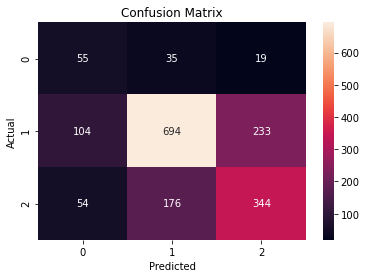

In [65]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred_baseline)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
#Visualizing the confusion matrix
cm = confusion_matrix(y_test,y_pred_baseline)



### Cross Validation

Cross-validation tests whether the model generalises well to unseen data by training and evaluating on 5 different splits of the training data. This verifies the model is not overfitting to one particular train/test split.



In [66]:
# check how stable the model is using cross-validation
cv_scores = cross_val_score(lr_baseline, X_train_resampled, y_train_resampled,  cv=5, scoring='f1_macro')

print("Cross-validation F1 scores:", cv_scores)
print("Mean CV F1:", cv_scores.mean())



Cross-validation F1 scores: [0.77085017 0.78714691 0.78059225 0.81960412 0.82711443]
Mean CV F1: 0.797061577453461


## Hyperparameter tuning

In [67]:
from sklearn.model_selection import GridSearchCV

# parameter grid 
param_grid = {
    'C': [0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear']
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_search.fit(X_train_resampled, y_train_resampled)

print("Best parameters:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)




Best parameters: {'C': 10, 'solver': 'lbfgs'}
Best CV score: 0.8266387429677005


In [68]:
# use best model from grid search
best_lr = grid_search.best_estimator_

best_lr.fit(X_train_resampled, y_train_resampled)

#predictions
y_pred = best_lr.predict(X_test_tfidf)

In [69]:
#evaluation oftuned model
acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')
weighted_f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy:", acc)
print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.6546091015169195
Macro F1: 0.5682046536018334
Weighted F1: 0.6592155780629931

Classification Report:

              precision    recall  f1-score   support

           0       0.34      0.45      0.39       109
           1       0.75      0.70      0.73      1031
           2       0.57      0.60      0.59       574

    accuracy                           0.65      1714
   macro avg       0.56      0.59      0.57      1714
weighted avg       0.67      0.65      0.66      1714



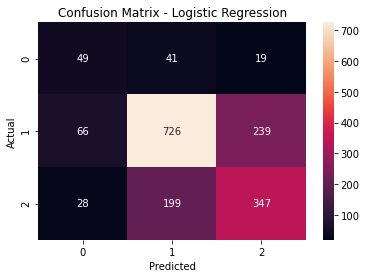

In [70]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()